# Local Slow Oscillation Targeting

In [5]:
import numpy as np
from scipy import signal
from scipy import signal
import matplotlib.pyplot as plt
from sleepstim.Online_testing.mock_simulation import *
import seaborn as sns 
import yasa
import mne
import pandas as pd
import mne
import math
import pickle
sns.set(style='darkgrid', font_scale=1.2)

## Method

Steps of algorithm:

1. Extract first 220 minutes of recorded high-density EEG data (64 channels)
2. Perform SO detection on extracted data
    a. bandpass sos iir butterworth filter [0.3-30 Hz]  
    b. re-reference to linked mastoids average  
    b. inclusion criteria of detected SO:
        - Frequency bounds: [0.3-1.5 Hz]
        - Time bounds: Negative halfwave duration: [0.3-1.5 s],  
                       Positive halfwave duration: [0.1-1 s]
        - Amplitude (trough to peak) bounds: [50-500 microvolts] 
        
3. Create epochs centered around troughs and peaks [-1980-20 ms] for each of C3, C4, and Fz (Target channels - CSD)
    a. Low-pass sos iir butterworth filter [4 Hz]
    b. Median correction of signal (drift correction) 
    c. [Re-reference to Linked Mastoids] - remove
    d. Perform surface Laplacian transformation [lambda2=1e-5, stiffness=4, n_legendre_terms=50]
    e. Detect bad channels based on i. standard deviation, ii. mean, iii. median absolute deviation, iv. skewness, v. kurtosis, vi. amplitude, vii. highest density intervals, viii. number of zero crossings
    f. Interpolate bad channels with spherical splines
    g. Append trials where target channel source density:
        - exceeds 20th or 80th percentile of channel values depending on whether target state is trough or peak
        - exceeds mean of the target channel value in the last 40 ms [-20 - +20 ms]
        
Statistical analysis:

1. Include nights with more than 50 epochs/trials 
2. Statistical tests:
    a. Contrast against 0: C3 Neg Peak, C4 Neg Peak, Fz Neg Peak, C3 Pos Peak, C4 Pos Peak, Fz Pos Peak 
    b. Contrasts: [C3 Neg Peak - C4 Neg Peak], [Fz Neg Peak - C4 Neg Peak], [C3 Pos Peak - C4 Pos Peak], [Fz Pos Peak - C4 Pos Peak]
        - RM anova with channels as within factor to derive effect size of targeting as compared to non-targeted sensors
    c. Topomap similarity (Fisher's z-transformed Spearman's rho):
       - Within target state group mean versus between target state individual map correlations for (C3 Neg Peak, C4 Neg Peak, Fz Neg Peak, C3 Pos Peak, C4 Pos Peak, Fz Pos Peak)
       - LMM for comparison (within, between) and target channel means (C3, C4, Fz)

In [6]:
## Load dataframe for statistical test on subject vs. group correlations 
df = pd.read_pickle('/media/administrator/data/Study_2_data/stats/df.p')
df_evoked = pd.read_pickle('/media/administrator/data/Study_2_data/stats/df_contrast.p')
df = df[df.Reference=='csd']
df_evoked = df_evoked[df_evoked.Reference=='csd']

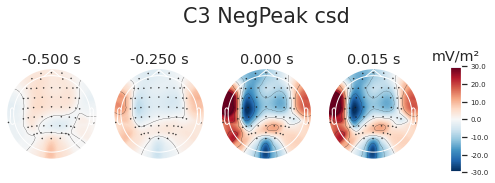

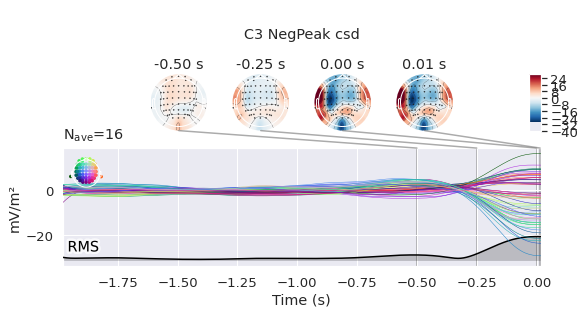

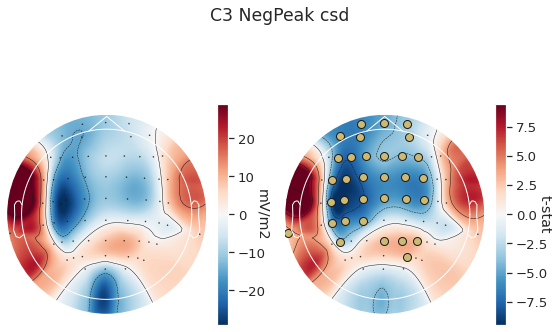

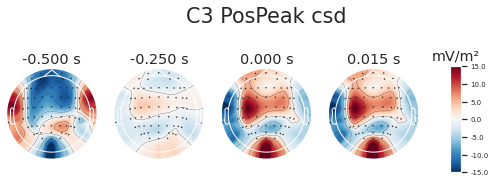

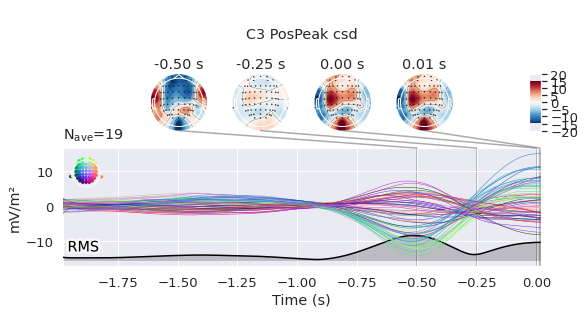

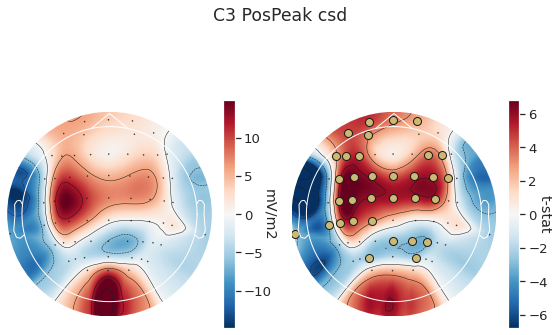

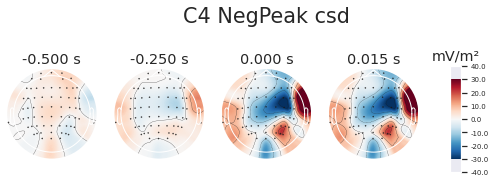

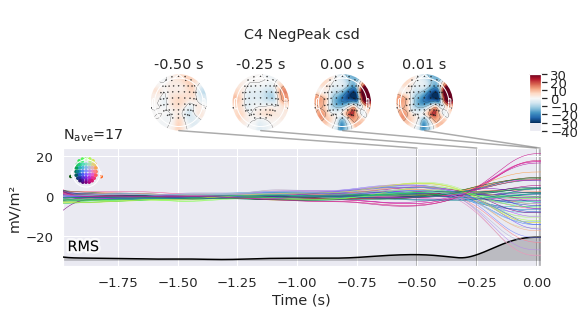

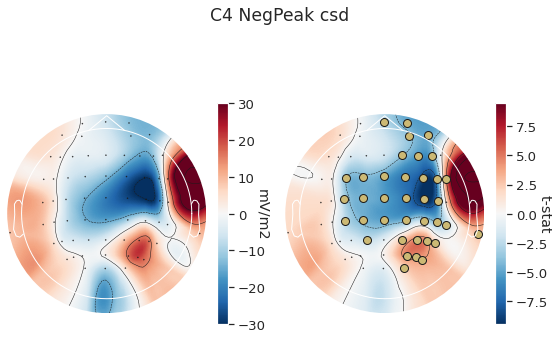

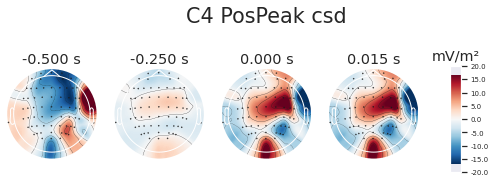

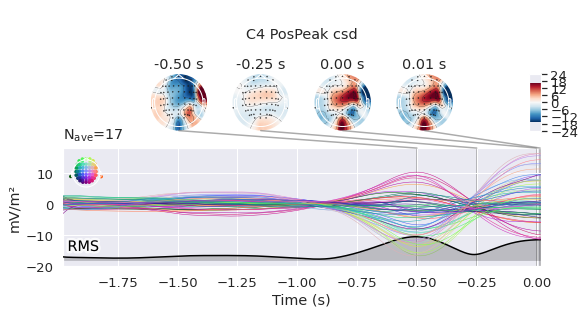

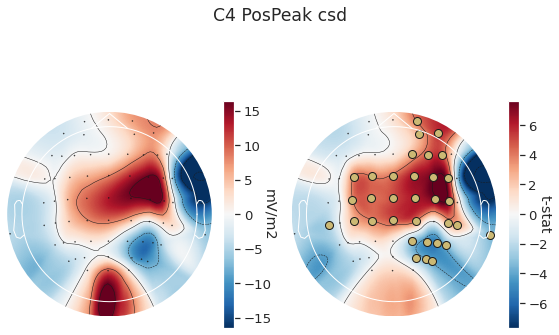

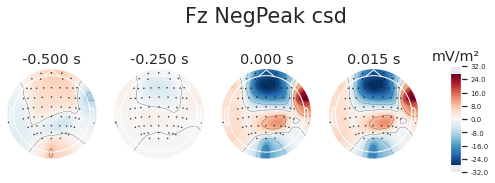

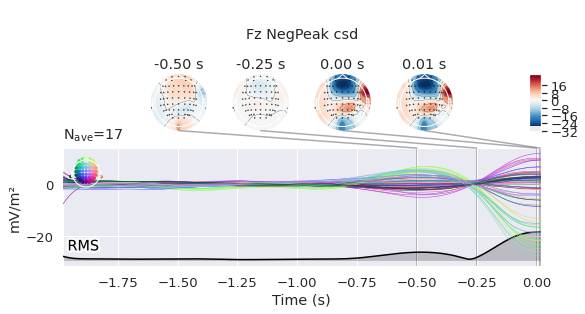

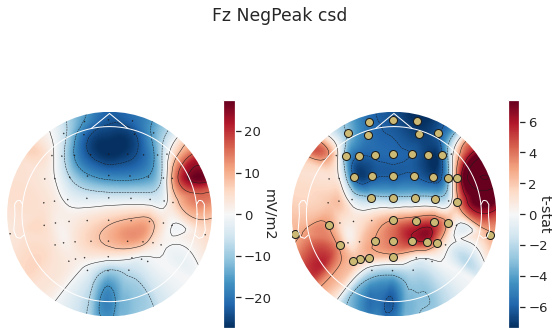

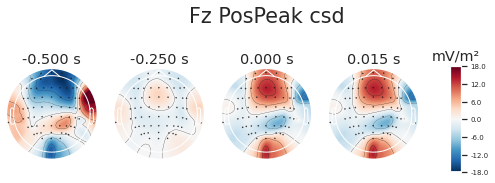

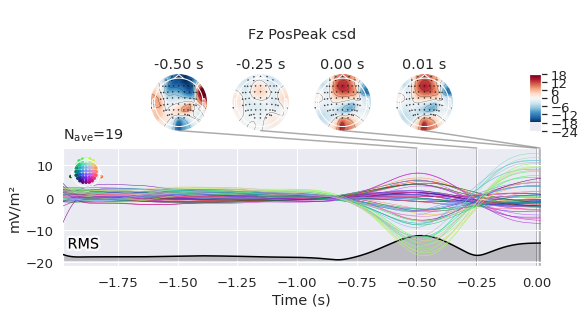

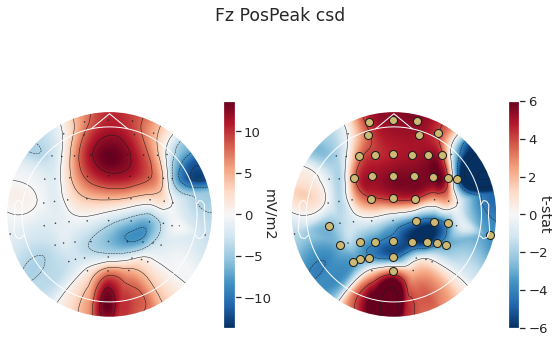

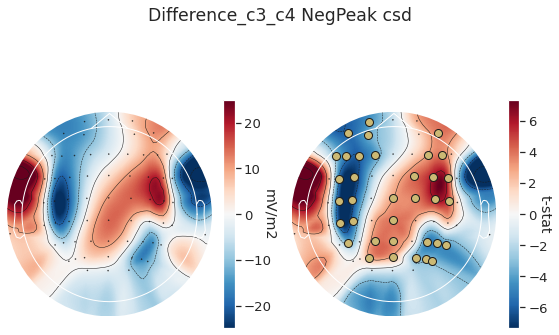

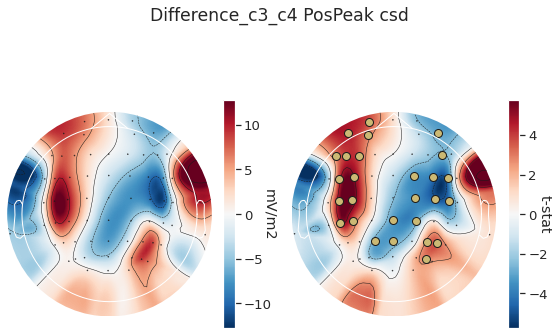

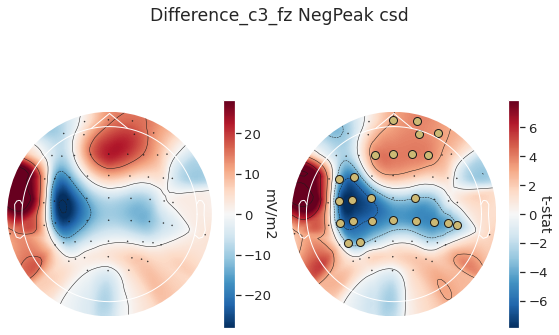

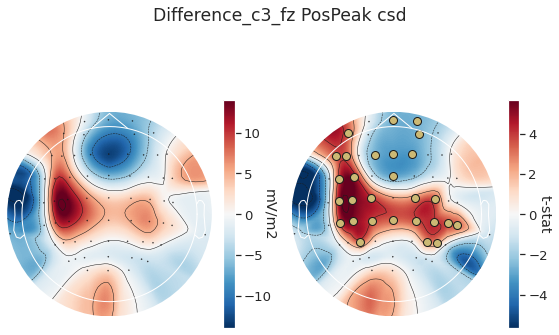

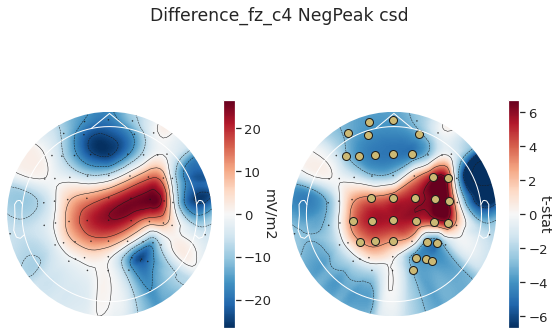

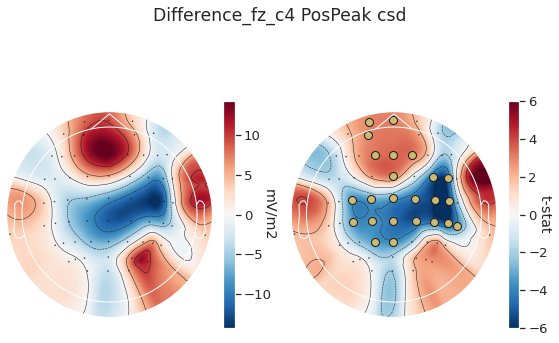

In [8]:
# compute gavs per target chan, peak, and reference
def plot(df):
    for idx, item in enumerate(df.groupby(['Target_Chan','Peak','Reference'])):
        # grand averages of all nights
        gavs = mne.grand_average(list(item[1].Epochs))
        # plotting args
        ts_args = dict(spatial_colors = True, gfp=True, time_unit='s')
        topomap_args = dict(outlines = 'head', time_unit='s', 
                            time_format = "%0.2f s")
        times = np.asarray([-0.50, -0.25, 0, .015])

        gavs.plot_topomap(times=times, title=f'{item[0][0]} {item[0][1]} {item[0][2]}')
        gavs.plot_joint(times, ts_args = ts_args, topomap_args = topomap_args,
                        title=f'{item[0][0]} {item[0][1]} {item[0][2]}')
        group_stats(gavs, obj=item,
                    title=f'{item[0][0]} {item[0][1]} {item[0][2]}')
        
    # plot and compute 2nd statistical query
    group_stats_contrast(df_evoked, 
                         gavs=gavs, path=None, title=None, save=False)

plot(df)

('C3', 'NegPeak', 'csd')
('C3', 'PosPeak', 'csd')
('C4', 'NegPeak', 'csd')
('C4', 'PosPeak', 'csd')
('Fz', 'NegPeak', 'csd')
('Fz', 'PosPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPe

/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and 

 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'PosPeak', 'csd'),

/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and 

0 NegPeak csd C3
Proportion of subjects with higher correlation values within versus between: 1.0
1 NegPeak csd C4
Proportion of subjects with higher correlation values within versus between: 0.941
2 NegPeak csd Fz
Proportion of subjects with higher correlation values within versus between: 0.941
3 PosPeak csd C3
Proportion of subjects with higher correlation values within versus between: 0.842
4 PosPeak csd C4
Proportion of subjects with higher correlation values within versus between: 1.0
5 PosPeak csd Fz
Proportion of subjects with higher correlation values within versus between: 1.0


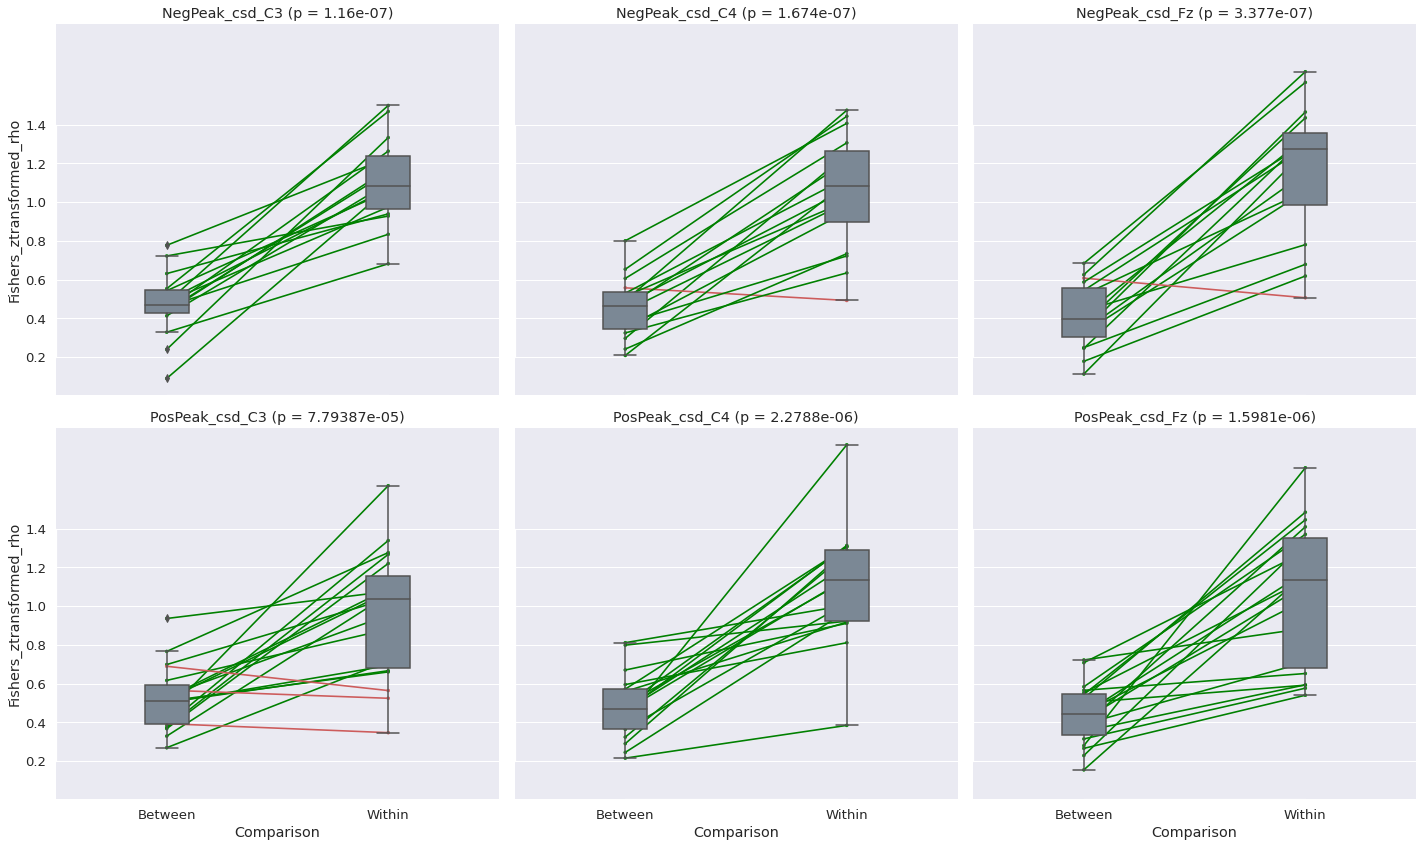

NegPeak csd
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Model refit with orthogonal polynomial contrasts)
          SS         MS  NumDF     DenomDF      F-stat         P-val  Sig  \
0   0.024081   0.012040      2  125.780474    0.194415  8.235628e-01        
1  14.652466  14.652466      1  125.861558  236.592161  1.081732e-30  ***   
2   0.135593   0.067796      2  125.780474    1.094702  3.378061e-01        

  Tested_effect      Comparison  
0  Target_means  NegPeak_csd_Fz  
1    Comparison  NegPeak_csd_Fz  
2   Interaction  NegPeak_csd_Fz  
PosPeak csd
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Model refit with orthogonal polynomial contrasts)
          SS         MS  NumDF     DenomDF      F-stat         P-val  Sig  \
0   0.077183   0.038591      2  138.924832    0.554526  5.756106e-01        
1  11.055476  11.055476      1  137.863855  158.858379  1.039983e-24  ***   
2   

<Figure size 432x288 with 0 Axes>

In [7]:
p_path = '/media/administrator/data/Study_2_data/stats/'
group_stats_topo_correlations(df, p_path)

('C3', 'NegPeak', 'csd')
('C3', 'PosPeak', 'csd')
('C4', 'NegPeak', 'csd')
('C4', 'PosPeak', 'csd')
('Fz', 'NegPeak', 'csd')
('Fz', 'PosPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPe

/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and 

 Within: ('C3', 'PosPeak', 'csd'), Between: ('Fz', 'PosPeak', 'csd')
 Within: ('C4', 'PosPeak', 'csd'), Between: ('Fz', 'PosPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('C4', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C3', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('C4', 'NegPeak', 'csd')
 Within: ('Fz', 'NegPeak', 'csd'), Between: ('Fz', 'NegPeak', 'csd')
 Within: ('C3', 'NegPeak', 'csd'),

/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_corr = df_corr.append(pd.DataFrame({'Subject_Cond': unity,
/home/administrator/sleep_stimulation/sleepstim/Online_testing/mock_simulation.py:1090: FutureWarning: The frame.append method is deprecated and 

Peak     Reference  Target_means
NegPeak  csd        C3              1.000000
                    C4              0.823529
                    Fz              0.882353
PosPeak  csd        C3              0.789474
                    C4              0.882353
                    Fz              0.947368
Name: Within_v_Between, dtype: float64
0 NegPeak csd C3
Proportion of subjects with higher correlation values within versus between: 1.0
1 NegPeak csd C4
Proportion of subjects with higher correlation values within versus between: 0.941
2 NegPeak csd Fz
Proportion of subjects with higher correlation values within versus between: 0.941
3 PosPeak csd C3
Proportion of subjects with higher correlation values within versus between: 0.842
4 PosPeak csd C4
Proportion of subjects with higher correlation values within versus between: 1.0
5 PosPeak csd Fz
Proportion of subjects with higher correlation values within versus between: 1.0


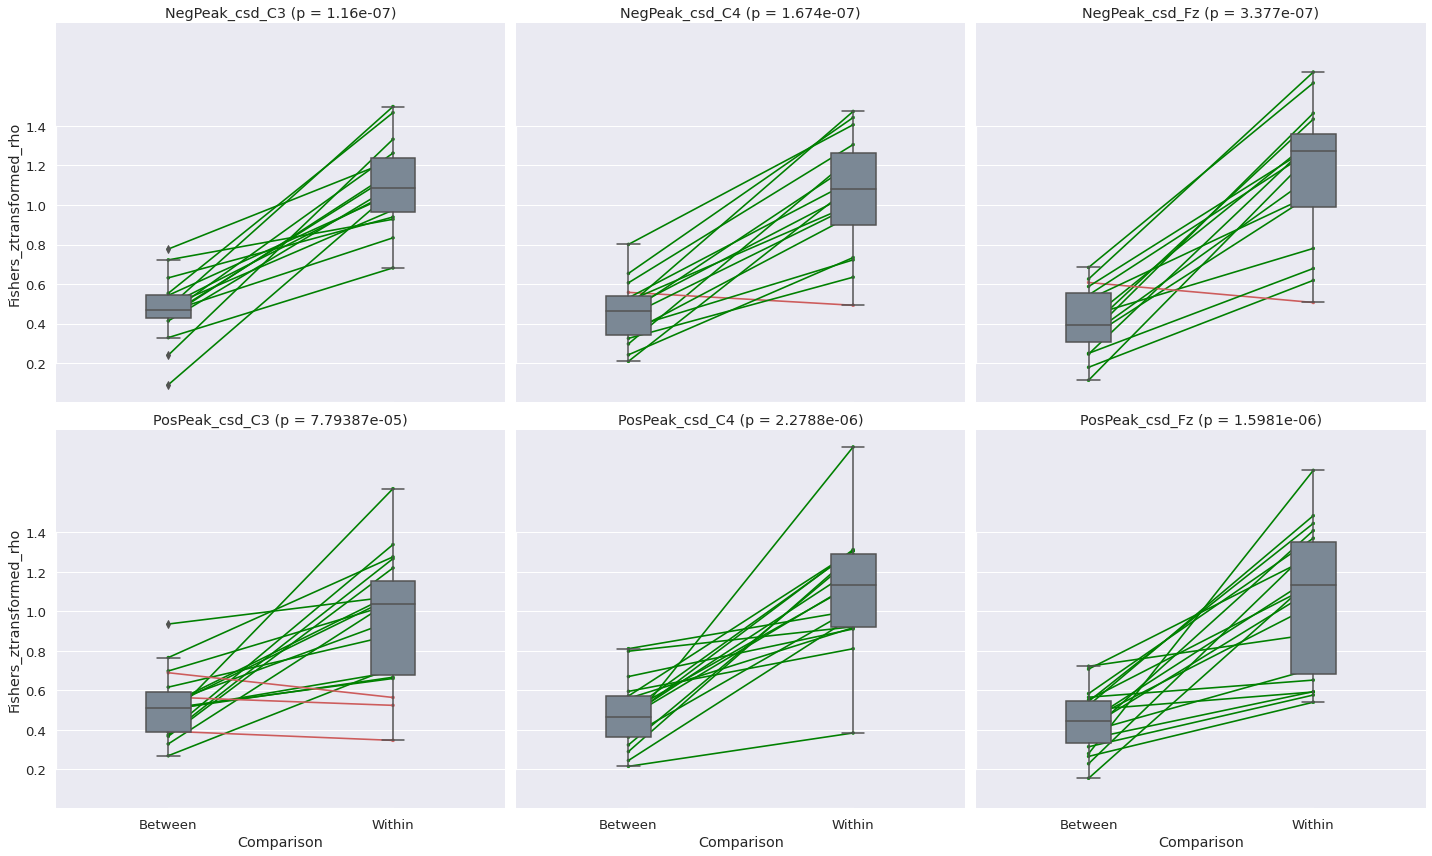

NegPeak csd
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Model refit with orthogonal polynomial contrasts)
          SS         MS  NumDF     DenomDF      F-stat         P-val  Sig  \
0   0.024081   0.012040      2  125.780474    0.194415  8.235628e-01        
1  14.652466  14.652466      1  125.861558  236.592161  1.081732e-30  ***   
2   0.135593   0.067796      2  125.780474    1.094702  3.378061e-01        

  Tested_effect      Comparison  
0  Target_means  NegPeak_csd_Fz  
1    Comparison  NegPeak_csd_Fz  
2   Interaction  NegPeak_csd_Fz  
PosPeak csd
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Model refit with orthogonal polynomial contrasts)
          SS         MS  NumDF     DenomDF      F-stat         P-val  Sig  \
0   0.077183   0.038591      2  138.924832    0.554526  5.756106e-01        
1  11.055476  11.055476      1  137.863855  158.858379  1.039983e-24  ***   
2   

<Figure size 432x288 with 0 Axes>

In [4]:
group_stats_topo_correlations(df, p_path)